In [ ]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [ ]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/21 15:33:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/21 15:33:30 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# Load data


In [ ]:
path_to_release_folder = "../../../data/25.06/"


In [ ]:
sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")


In [ ]:
disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)


In [ ]:
efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)


In [ ]:
chembl_evidence.show(1)


25/11/21 15:37:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

In [ ]:
l2g_full = session.spark.read.parquet("../../../data/intermediate_files/l2g_full_for_enrichment/")
l2g_full.count()


70400

In [ ]:
l2g_full.show(1)


+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|        studyLocusId|             studyId|         geneId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|
+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|ENSG00000152954|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|
+--------------------+--------------------+---------------+-----------------+---

In [10]:
g_p_s = session.spark.read.parquet("../../../data/intermediate_files/genes_therapeutic_areas")
g_p_s.count()


8285

# Test run


In [ ]:
import pandas as pd

all_enrich = []

for year in range(2025, 2026):
    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=l2g_full.filter(f.col("year") <= year).drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["datasource"] = str(year)
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)


In [ ]:
all_enrich


[  clinicalPhase  odds_ratio       p_value    ci_low   ci_high  \
 0            2+    1.746148  1.154068e-06  1.375083  2.217346   
 1            3+    2.060942  7.941172e-22  1.773924  2.394399   
 2            4+    3.618578  3.534571e-49  3.093638  4.232591   
 
    Relative success  ci_rs_low  ci_rs_high    rs_p_value  \
 0          1.076425   1.050129    1.103380  5.340474e-09   
 1          1.398926   1.321405    1.480995  8.135878e-31   
 2          2.764540   2.483639    3.077211  3.161170e-77   
 
    no_evid-low_clinphase  no_evid-high_clinphase  yes_evid-low_clinphase  \
 0                   6087                   30548                      76   
 1                  20294                   16341                     279   
 2                  32313                    4322                     500   
 
    yes_evid-high_clinphase  total_indirect_assoc datasource   drugsource  
 0                      666                151704       2025  full_chembl  
 1                      46

# Different gene categories


In [21]:
combined_evidence = session.spark.read.parquet("../../../data/intermediate_files/list_of_genes_32_categories")
combined_evidence.count()


82410

In [59]:
combined_evidence.groupBy("source").count().show(100)


+--------------------+-----+
|              source|count|
+--------------------+-----+
|        all_diseases| 8285|
|          hc_paralog| 4173|
|    distant_ortholog|  830|
|       cancer_ChEMBL|  649|
|         gene_burden|  557|
|                omim| 4182|
|           inComplex| 3530|
|  cancer_driver_gene|  368|
|            fusil_DL|  785|
|      withdrawn_drug|  166|
|   non_cancer_ChEMBL|  958|
|       selectiveGene|  930|
|      essential_gene| 1489|
|           gwas_eQTL| 3945|
|       gwas_with_pav| 1574|
|            fusil_CL|  415|
|            fusil_VP| 1862|
|            fusil_SV|  419|
|       liable_target|  214|
|            orphanet| 3814|
|              ChEMBL| 1137|
|          dd_related|  861|
|        pharmacogene|  538|
|            fusil_VN|  321|
|trial_safety_concern|  440|
|  mouse_ko_mortality| 1022|
|           All genes|20083|
|       non_essential|  766|
|       lof_constr_Q4| 4520|
|       lof_constr_Q2| 4532|
|       lof_constr_Q3| 4519|
|       lof_co

In [ ]:
gwas_diseases = (
    combined_evidence.filter(f.col("source") == "all_diseases")
    .select("targetId")
    .distinct()
    .rdd.flatMap(lambda r: r)
    .collect()
)
len(gwas_diseases)


8285

In [32]:
all_genes = (
    combined_evidence.filter(f.col("source") == "All genes")
    .select("targetId")
    .distinct()
    .rdd.flatMap(lambda r: r)
    .collect()
)
len(all_genes)


20083

In [ ]:
omim = (
    combined_evidence.filter(f.col("source") == "omim").select("targetId").distinct().rdd.flatMap(lambda r: r).collect()
)
len(omim)


4182

In [61]:
orphanet = (
    combined_evidence.filter(f.col("source") == "orphanet")
    .select("targetId")
    .distinct()
    .rdd.flatMap(lambda r: r)
    .collect()
)
len(orphanet)


3814

In [62]:
gene_burden = (
    combined_evidence.filter(f.col("source") == "gene_burden")
    .select("targetId")
    .distinct()
    .rdd.flatMap(lambda r: r)
    .collect()
)
len(gene_burden)


557

In [ ]:
measurement_evidence = session.spark.read.parquet(
    "../../../data/intermediate_files/combined_evidence_with_measurements/"
)


In [ ]:
measurement_evidence = measurement_evidence.filter(f.col("source") == "all_measurements").select("targetId").distinct()
measurement_genes = measurement_evidence.select("targetId").distinct().rdd.flatMap(lambda r: r).collect()
len(measurement_genes)


15160

In [ ]:
def ordered_union(a, b, c):
    seen = set()
    out = []
    for lst in (a, b, c):
        for x in lst:
            if x not in seen:
                seen.add(x)
                out.append(x)
    return out


measurement_only = [g for g in measurement_genes if g not in set(gwas_diseases)]
combined_set = set(gwas_diseases) | set(measurement_genes)
all_genes_minus_measurement_and_diseases = [g for g in all_genes if g not in combined_set]


In [ ]:
union_of_sets = set(gwas_diseases) & (set(gene_burden) | set(orphanet) | set(omim))
len(union_of_sets)


2556

In [ ]:
intersect_of_sets = set(gwas_diseases) & set(orphanet) & set(omim)
len(intersect_of_sets)


1678

In [ ]:
len(measurement_only)


7356

In [ ]:
len(all_genes_minus_measurement_and_diseases)


4442

In [ ]:
omim_orphanet = set(omim) | set(orphanet)
len(omim_orphanet)


4735

In [ ]:
len(gwas_diseases)


8285

In [ ]:
groups = {
    "gwas_diseases": gwas_diseases,
    "no_gwas": all_genes_minus_measurement_and_diseases,
    "measurement_only": measurement_only,
    "omim_orphanet": omim_orphanet,
}


# Enrichemnt on groups


In [92]:
l2g_full.show(1)


+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|        studyLocusId|             studyId|         geneId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|
+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|ENSG00000152954|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|
+--------------------+--------------------+---------------+-----------------+---

In [93]:
chembl = chemblDrugEnrichment.process_chembl_evidence(chembl_evidence, efo_to_remove)
chembl_for_analysis = chembl.drop("maxClinicalPhase").withColumn("resourceScore", f.lit(1)).cache()
chembl_for_analysis.count()


25/11/21 20:37:25 WARN CacheManager: Asked to cache already cached data.


37377

In [94]:
chembl_for_analysis.show(1)


+---------------+-----------+-------------+
|       targetId|  diseaseId|resourceScore|
+---------------+-----------+-------------+
|ENSG00000007314|EFO_0000555|            1|
+---------------+-----------+-------------+
only showing top 1 row



In [101]:
group_ids = list(groups.keys())
all_enrich = []
for groupId in group_ids:
    print(f"Processing group: {groupId} (n={len(groups[groupId])})")

    tbl = chembl_for_analysis.filter(f.col("targetId").isin(groups[groupId]))

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=tbl,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["group"] = groupId
    enrich["n"] = len(groups[groupId])
    all_enrich.append(enrich)

print("Done. Processed", len(group_ids), "groups.")


Processing group: gwas_diseases (n=8285)


25/11/21 23:58:28 WARN CacheManager: Asked to cache already cached data.
25/11/21 23:58:30 WARN CacheManager: Asked to cache already cached data.        
25/11/21 23:58:31 WARN DAGScheduler: Broadcasting large task binary with size 1212.7 KiB
25/11/21 23:58:34 WARN DAGScheduler: Broadcasting large task binary with size 1212.8 KiB
25/11/21 23:58:37 WARN DAGScheduler: Broadcasting large task binary with size 1213.7 KiB
25/11/21 23:58:40 WARN DAGScheduler: Broadcasting large task binary with size 1213.8 KiB
25/11/21 23:58:42 WARN DAGScheduler: Broadcasting large task binary with size 1212.8 KiB
25/11/21 23:58:45 WARN DAGScheduler: Broadcasting large task binary with size 1212.9 KiB
25/11/21 23:58:48 WARN DAGScheduler: Broadcasting large task binary with size 1213.7 KiB
25/11/21 23:58:51 WARN DAGScheduler: Broadcasting large task binary with size 1213.8 KiB
25/11/21 23:58:53 WARN DAGScheduler: Broadcasting large task binary with size 1212.8 KiB
25/11/21 23:58:56 WARN DAGScheduler: Broadcas

Processing group: no_gwas (n=4442)


25/11/21 23:59:14 WARN CacheManager: Asked to cache already cached data.
25/11/21 23:59:16 WARN CacheManager: Asked to cache already cached data.        
25/11/21 23:59:17 WARN DAGScheduler: Broadcasting large task binary with size 1107.6 KiB
25/11/21 23:59:19 WARN DAGScheduler: Broadcasting large task binary with size 1107.8 KiB
25/11/21 23:59:22 WARN DAGScheduler: Broadcasting large task binary with size 1108.6 KiB
25/11/21 23:59:25 WARN DAGScheduler: Broadcasting large task binary with size 1108.8 KiB
25/11/21 23:59:27 WARN DAGScheduler: Broadcasting large task binary with size 1107.7 KiB
25/11/21 23:59:30 WARN DAGScheduler: Broadcasting large task binary with size 1107.8 KiB
25/11/21 23:59:33 WARN DAGScheduler: Broadcasting large task binary with size 1108.6 KiB
25/11/21 23:59:35 WARN DAGScheduler: Broadcasting large task binary with size 1108.8 KiB
25/11/21 23:59:38 WARN DAGScheduler: Broadcasting large task binary with size 1107.7 KiB
25/11/21 23:59:40 WARN DAGScheduler: Broadcas

Processing group: measurement_only (n=7356)


25/11/21 23:59:59 WARN CacheManager: Asked to cache already cached data.
25/11/22 00:00:01 WARN CacheManager: Asked to cache already cached data.        
25/11/22 00:00:02 WARN DAGScheduler: Broadcasting large task binary with size 1187.3 KiB
25/11/22 00:00:05 WARN DAGScheduler: Broadcasting large task binary with size 1187.4 KiB
25/11/22 00:00:08 WARN DAGScheduler: Broadcasting large task binary with size 1188.3 KiB
25/11/22 00:00:11 WARN DAGScheduler: Broadcasting large task binary with size 1188.4 KiB
25/11/22 00:00:14 WARN DAGScheduler: Broadcasting large task binary with size 1187.4 KiB
25/11/22 00:00:17 WARN DAGScheduler: Broadcasting large task binary with size 1187.5 KiB
25/11/22 00:00:19 WARN DAGScheduler: Broadcasting large task binary with size 1188.3 KiB
25/11/22 00:00:22 WARN DAGScheduler: Broadcasting large task binary with size 1188.4 KiB
25/11/22 00:00:25 WARN DAGScheduler: Broadcasting large task binary with size 1187.4 KiB
25/11/22 00:00:28 WARN DAGScheduler: Broadcas

Processing group: omim_orphanet (n=4735)


25/11/22 00:00:45 WARN CacheManager: Asked to cache already cached data.
25/11/22 00:00:47 WARN CacheManager: Asked to cache already cached data.        
25/11/22 00:00:47 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
25/11/22 00:00:50 WARN DAGScheduler: Broadcasting large task binary with size 1115.8 KiB
25/11/22 00:00:53 WARN DAGScheduler: Broadcasting large task binary with size 1116.7 KiB
25/11/22 00:00:55 WARN DAGScheduler: Broadcasting large task binary with size 1116.8 KiB
25/11/22 00:00:57 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
25/11/22 00:01:00 WARN DAGScheduler: Broadcasting large task binary with size 1115.8 KiB
25/11/22 00:01:02 WARN DAGScheduler: Broadcasting large task binary with size 1116.7 KiB
25/11/22 00:01:05 WARN DAGScheduler: Broadcasting large task binary with size 1116.8 KiB
25/11/22 00:01:07 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
25/11/22 00:01:10 WARN DAGScheduler: Broadcas

Done. Processed 4 groups.


In [102]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,Relative success,ci_rs_low,ci_rs_high,rs_p_value,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,group,n
2,4+,1.350047,3.091163e-21,1.268470,1.436871,1.301631,1.232200,1.374975,4.272818e-21,16889,2008,15924,2556,63787,gwas_diseases,8285
5,4+,0.737972,1.832787e-10,0.670466,0.812274,0.763262,0.700128,0.832090,8.631776e-10,27908,4040,4905,524,18262,no_gwas,4442
8,4+,0.910954,5.797773e-03,0.852470,0.973450,0.921243,0.868916,0.976721,5.969472e-03,21699,3112,11114,1452,41889,measurement_only,7356
11,4+,1.021311,5.064945e-01,0.959878,1.086676,1.018686,0.964684,1.075712,5.052848e-01,15594,2145,17219,2419,66111,omim_orphanet,4735


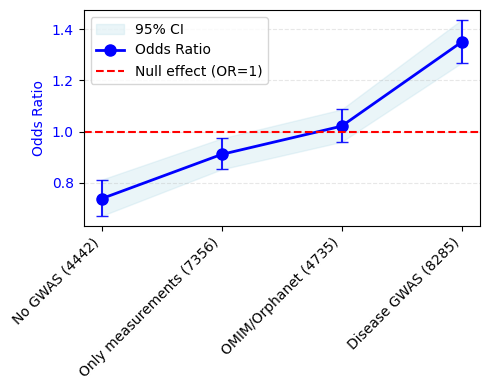

In [116]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by odds_ratio (descending) and reset index
df = combined_enrich_4.sort_values("odds_ratio", ascending=True).reset_index(drop=True)

# x positions (ordinal)
x = np.arange(len(df))
# labels = df["group"].astype(str).tolist()
labels_1 = ["No GWAS", "Only measurements", "OMIM/Orphanet", "Disease GWAS"]
labels = [f"{lab} ({c})" for lab, c in zip(labels_1, list(df["n"]))]

# y values and CIs (cast to float)
odds = df["odds_ratio"].astype(float).values
ci_lo = df["ci_low"].astype(float).values
ci_hi = df["ci_high"].astype(float).values

# Plot
fig, ax = plt.subplots(figsize=(5, 4))

# CI ribbon
ax.fill_between(x, ci_lo, ci_hi, color="lightblue", alpha=0.25, label="95% CI")

# OR line + points
ax.plot(x, odds, "o-", color="blue", linewidth=2, markersize=8, label="Odds Ratio")

# Error bars (explicit)
yerr = np.vstack([odds - ci_lo, ci_hi - odds])
ax.errorbar(x, odds, yerr=yerr, fmt="none", ecolor="blue", alpha=0.9, capsize=4)

# Null line
ax.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="Null effect (OR=1)")

# x ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)

# Labels, grid, legend
# ax.set_xlabel("Group", fontsize=12)
ax.set_ylabel("Odds Ratio", fontsize=10, color="blue")
ax.tick_params(axis="y", labelcolor="blue")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper left", fontsize=10)

# plt.title("Drug Target Enrichment by Group (ordered by OR)", fontsize=13)
plt.tight_layout()
plt.show()
